In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_excel(
    "notebooks/DecarbonizationTechnologyDataset.xlsx",
    sheet_name="Technology Dataset",
    header=2
)

df.head()

,Technology,Full Name,Technology Readiness\nLevel (TRL),CapEx\n(INR Cr),OpEx Change\n(INR Cr/yr),Energy Saving\n(MWh/yr),CO₂ Reduction\n(Mt CO₂/yr),Payback\nPeriod (yrs),Lifetime\n(yrs),Applicability in\nIndian ISP,Status,Source / Reference
0,CDQ,Coke Dry Quenching,9,80,-5,5000,1.0,4,20,BF-BOF route; coke ovens,Commercially deployed,JISF; WSA Tech Report 2022
1,PCI,Pulverized Coal Injection,9,40,-8,Coal reduction (approx)150 kg/tHM,0.5,3,15,Blast Furnace,Widely deployed in India,Tata Steel; SAIL Tech Reports
2,TRT,Top Pressure Recovery Turbine,9,30,-3,3500,0.7,4,25,Blast Furnace top gas,"Deployed at JSW, Tata",IEA Iron & Steel 2020
3,BOFG Recovery,BOF Gas Recovery & Reuse,8,50,-4,4000,0.9,5,20,BOF Steelmaking shops,Partially deployed in India,WSA; IEAGHG 2021
4,EAF Upgrade,Electric Arc Furnace (Scrap-based),9,300,10,-2000,1.5,8,25,Scrap-rich regions; DRI+EAF,"Growing in India (JSW, Essar)",IEA; CRU 2023


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 10
Columns : 12
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Technology                        10 non-null     str    
 1   Full Name                         10 non-null     str    
 2   Technology Readiness
Level (TRL)  10 non-null     int64  
 3   CapEx
(INR Cr)                    10 non-null     int64  
 4   OpEx Change
(INR Cr/yr)           10 non-null     int64  
 5   Energy Saving
(MWh/yr)            10 non-null     object 
 6   CO₂ Reduction
(Mt CO₂/yr)         10 non-null     float64
 7   Payback
Period (yrs)              10 non-null     int64  
 8   Lifetime
(yrs)                    10 non-null     int64  
 9   Applicability in
Indian ISP       10 non-null     str    
 10  Status                            10 non-null     str    
 11  Source / Reference                10 non-null     str    
dtyp

In [4]:
df.columns

Index(['Technology', 'Full Name', 'Technology Readiness\nLevel (TRL)',
       'CapEx\n(INR Cr)', 'OpEx Change\n(INR Cr/yr)',
       'Energy Saving\n(MWh/yr)', 'CO₂ Reduction\n(Mt CO₂/yr)',
       'Payback\nPeriod (yrs)', 'Lifetime\n(yrs)',
       'Applicability in\nIndian ISP', 'Status', 'Source / Reference'],
      dtype='str')

In [5]:
df.isnull().sum()

Technology                           0
Full Name                            0
Technology Readiness\nLevel (TRL)    0
CapEx\n(INR Cr)                      0
OpEx Change\n(INR Cr/yr)             0
Energy Saving\n(MWh/yr)              0
CO₂ Reduction\n(Mt CO₂/yr)           0
Payback\nPeriod (yrs)                0
Lifetime\n(yrs)                      0
Applicability in\nIndian ISP         0
Status                               0
Source / Reference                   0
dtype: int64

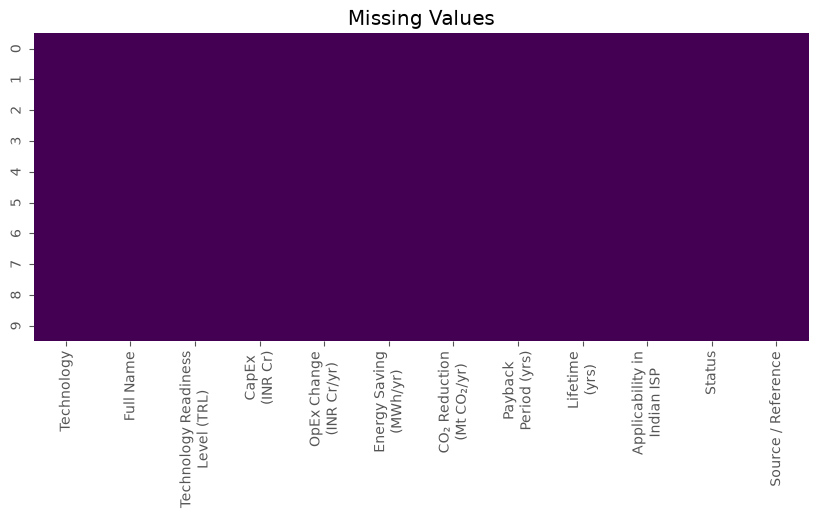

In [6]:
plt.figure(figsize=(10,4))

sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values")

plt.show()

In [7]:
print(df.duplicated().sum())

0


In [8]:
df.describe()

,Technology Readiness\nLevel (TRL),CapEx\n(INR Cr),OpEx Change\n(INR Cr/yr),CO₂ Reduction\n(Mt CO₂/yr),Payback\nPeriod (yrs),Lifetime\n(yrs)
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,7.500000,446.000000,8.100000,1.350000,7.200000,22.500000
std,1.649916,538.087147,22.849508,0.860555,3.966527,4.249183
min,5.000000,30.000000,-15.000000,0.400000,3.000000,15.000000
25%,6.250000,52.500000,-4.750000,0.750000,4.250000,20.000000
50%,8.000000,190.000000,-3.500000,1.100000,5.500000,22.500000
75%,9.000000,700.000000,17.500000,1.725000,9.500000,25.000000
max,9.000000,1500.000000,60.000000,3.000000,15.000000,30.000000


In [9]:
df.dtypes

Technology                               str
Full Name                                str
Technology Readiness\nLevel (TRL)      int64
CapEx\n(INR Cr)                        int64
OpEx Change\n(INR Cr/yr)               int64
Energy Saving\n(MWh/yr)               object
CO₂ Reduction\n(Mt CO₂/yr)           float64
Payback\nPeriod (yrs)                  int64
Lifetime\n(yrs)                        int64
Applicability in\nIndian ISP             str
Status                                   str
Source / Reference                       str
dtype: object

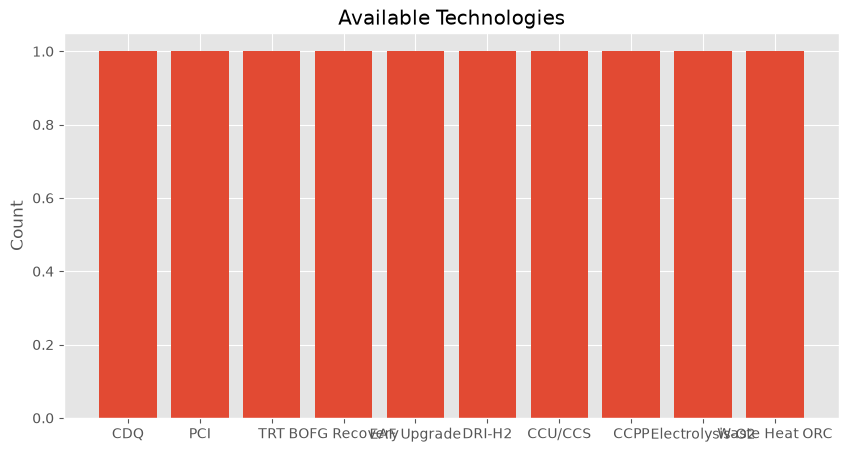

In [10]:
plt.figure(figsize=(10,5))

plt.bar(df["Technology"], np.ones(len(df)))

plt.ylabel("Count")

plt.title("Available Technologies")

plt.show()

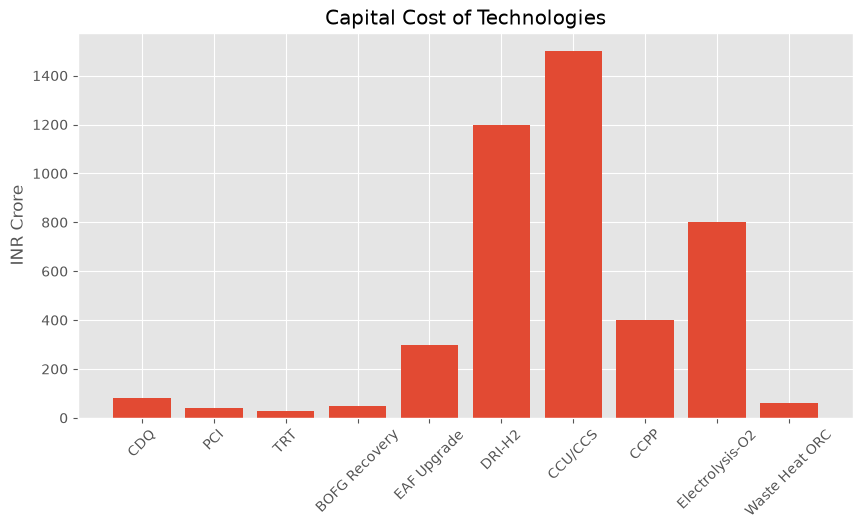

In [11]:
plt.figure(figsize=(10,5))

plt.bar(df["Technology"],
        df["CapEx\n(INR Cr)"])

plt.ylabel("INR Crore")

plt.title("Capital Cost of Technologies")

plt.xticks(rotation=45)

plt.show()

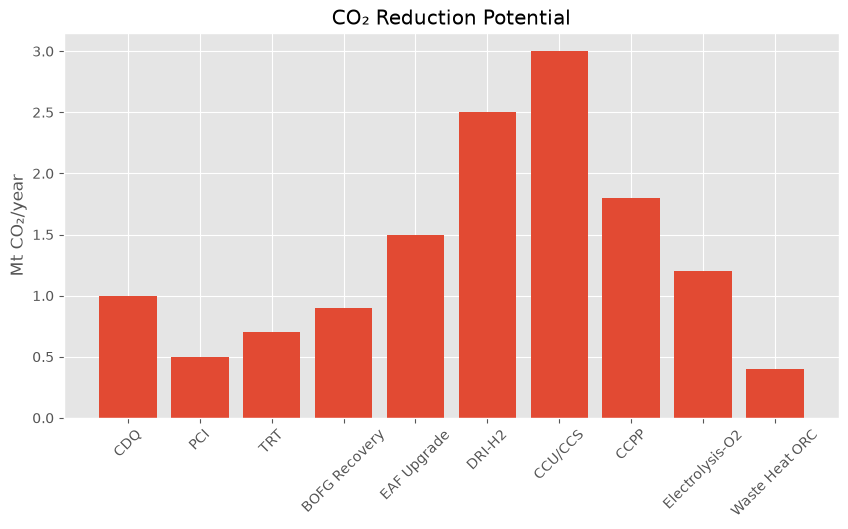

In [12]:
plt.figure(figsize=(10,5))

plt.bar(df["Technology"],
        df["CO₂ Reduction\n(Mt CO₂/yr)"])

plt.ylabel("Mt CO₂/year")

plt.title("CO₂ Reduction Potential")

plt.xticks(rotation=45)

plt.show()

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('int64'), dtype('<U33')) -> None

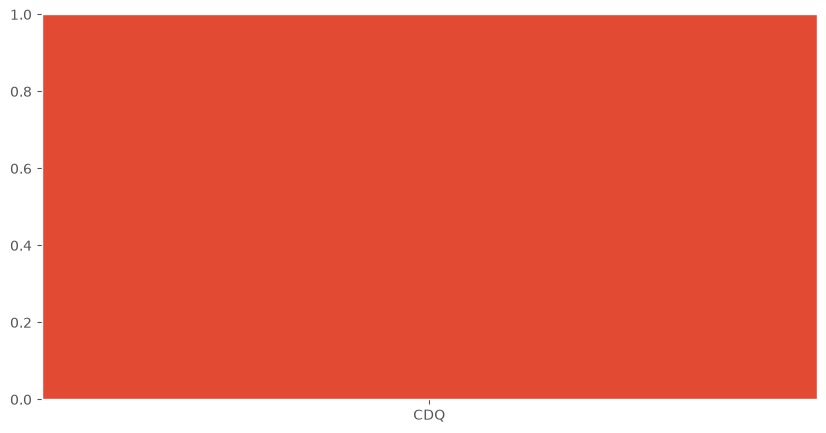

In [13]:
plt.figure(figsize=(10,5))

plt.bar(df["Technology"],
        df["Energy Saving\n(MWh/yr)"])

plt.ylabel("MWh/year")

plt.title("Energy Saving")

plt.xticks(rotation=45)

plt.show()

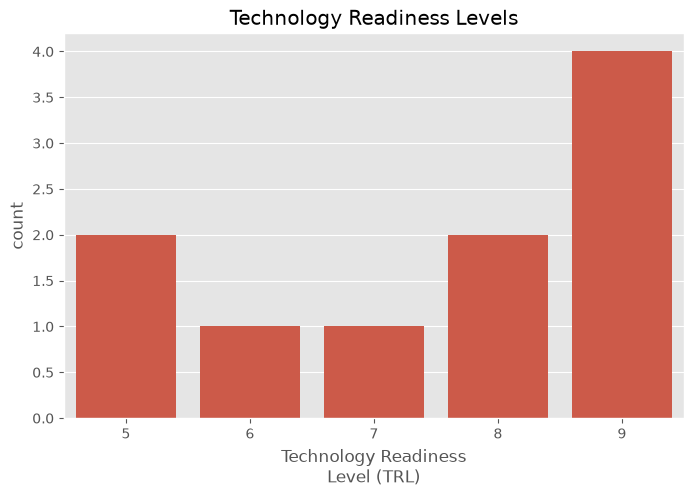

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Technology Readiness\nLevel (TRL)",
    data=df
)

plt.title("Technology Readiness Levels")

plt.show()

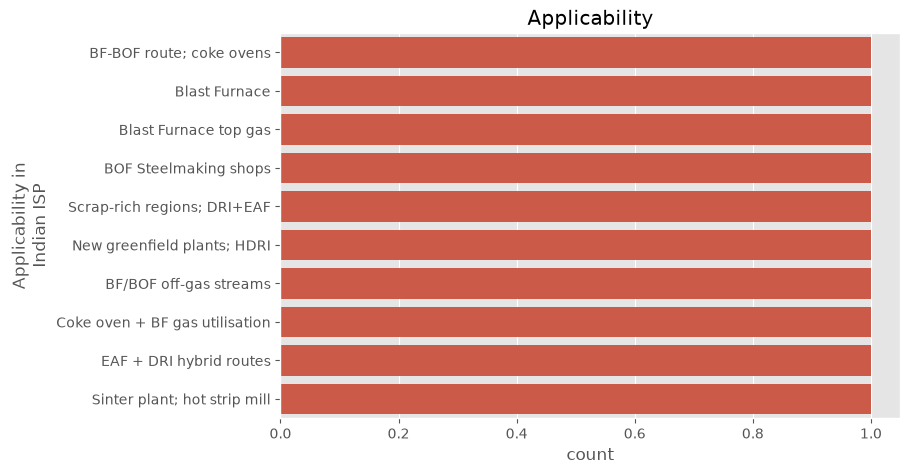

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Applicability in\nIndian ISP",
    data=df
)

plt.title("Applicability")

plt.show()

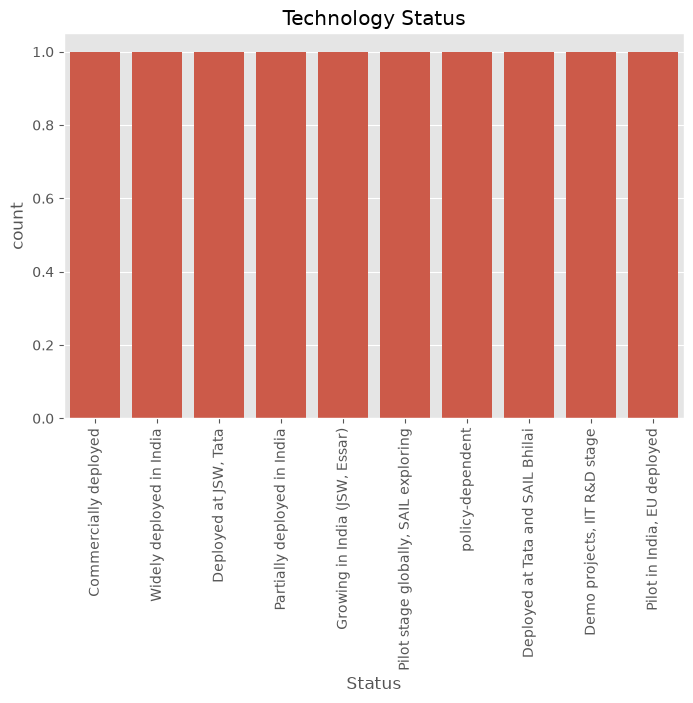

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Status",
    data=df
)

plt.title("Technology Status")
plt.xticks(rotation=90)
plt.show()

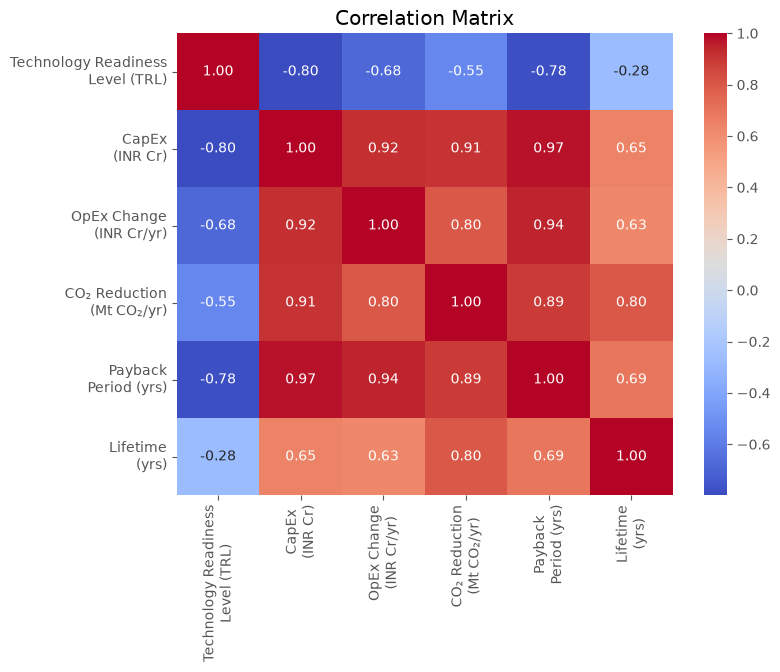

In [ ]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

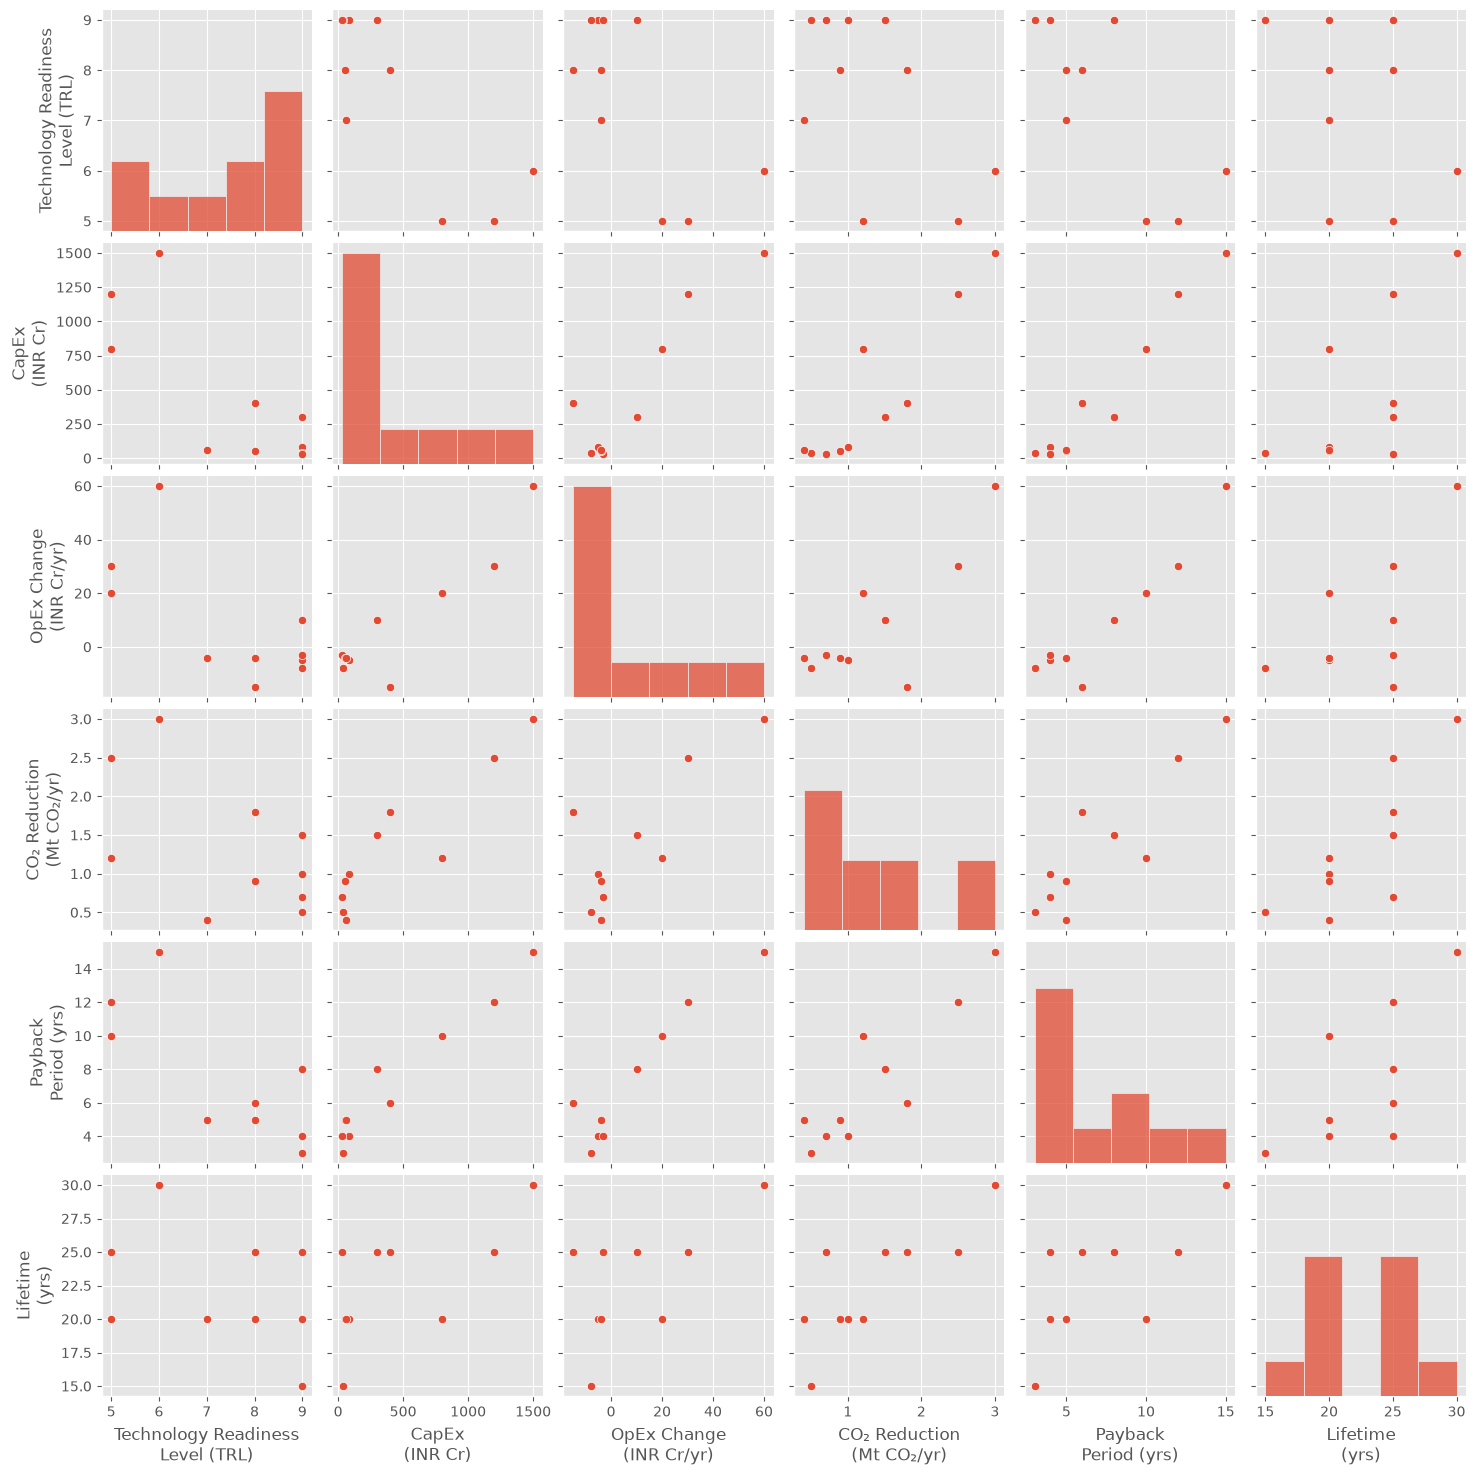

In [ ]:
sns.pairplot(numeric)

plt.show()

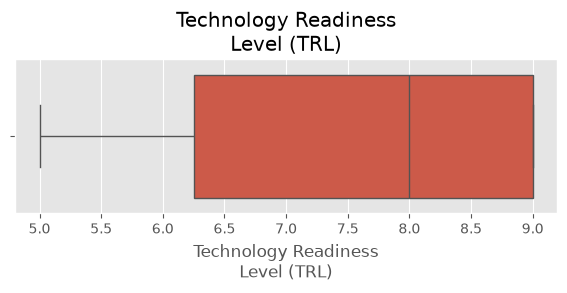

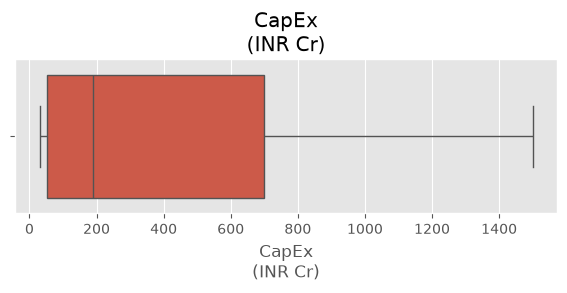

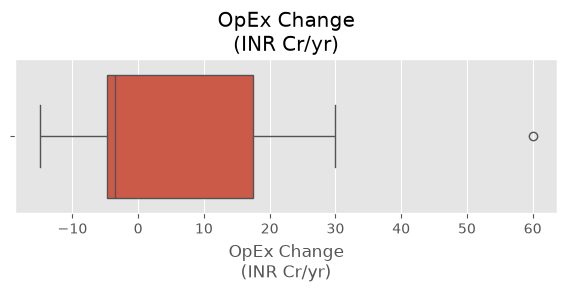

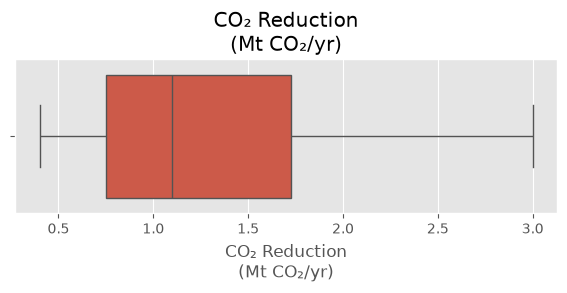

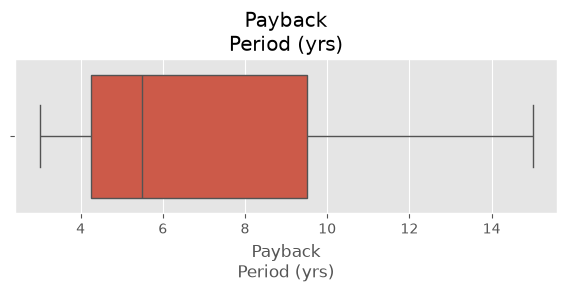

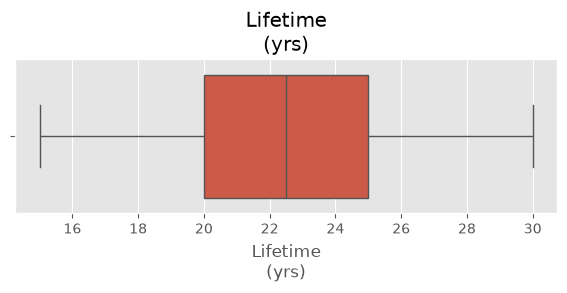

In [ ]:
for column in numeric.columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=numeric[column])

    plt.title(column)

    plt.show()

In [ ]:
top = df.sort_values(
    "CO₂ Reduction\n(Mt CO₂/yr)",
    ascending=False
)

top[["Technology",
     "CO₂ Reduction\n(Mt CO₂/yr)"]].head()

,Technology,CO₂ Reduction\n(Mt CO₂/yr)
6,CCU/CCS,3.0
5,DRI-H2,2.5
7,CCPP,1.8
4,EAF Upgrade,1.5
8,Electrolysis-O2,1.2


In [ ]:
payback = df.sort_values(
    "Payback\nPeriod (yrs)"
)

payback[["Technology",
         "Payback\nPeriod (yrs)"]]

,Technology,Payback\nPeriod (yrs)
1,PCI,3
0,CDQ,4
2,TRT,4
3,BOFG Recovery,5
9,Waste Heat ORC,5
7,CCPP,6
4,EAF Upgrade,8
8,Electrolysis-O2,10
5,DRI-H2,12
6,CCU/CCS,15


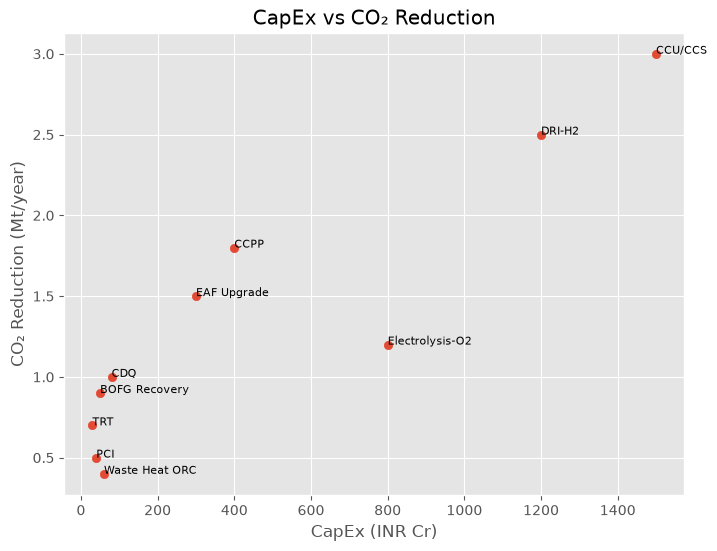

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["CapEx\n(INR Cr)"],
    df["CO₂ Reduction\n(Mt CO₂/yr)"]
)

for i in range(len(df)):
    plt.text(
        df["CapEx\n(INR Cr)"][i],
        df["CO₂ Reduction\n(Mt CO₂/yr)"][i],
        df["Technology"][i],
        fontsize=8
    )

plt.xlabel("CapEx (INR Cr)")
plt.ylabel("CO₂ Reduction (Mt/year)")
plt.title("CapEx vs CO₂ Reduction")

plt.show()

In [ ]:
df.to_excel(
    "notebooks/clean_decarbonization_technology.xlsx",
    index=False
)